# ProteinMPNN on homologous protein structures from the PDB

This notebook takes a seed protein sequence from a FASTA file, searches the **Protein Data Bank (PDB)** for homologous structures, downloads a small representative set of hits, extracts one protein chain per structure, and runs **ProteinMPNN** to generate designed sequences for each backbone.

The default seed comes from `inputs/kras_homologs_10.fa`, so the notebook works out of the box on a K-RAS-like example.


## Workflow

1. Load a seed sequence from a FASTA file.
2. Query the RCSB PDB sequence-search API for homologous polymer entities.
3. Keep a small non-redundant set of PDB entries.
4. Download the corresponding PDB files.
5. Extract one sufficiently long protein chain from each structure.
6. Run `ProteinMPNN` on each extracted backbone.
7. Collect the generated sequences into FASTA and CSV summaries.

This is a practical structure-conditioned design workflow rather than a sequence-space visualization method.


## Requirements

This notebook expects:

- `torch`, `biopython`, `requests`, and `matplotlib`
- either `PROTEINMPNN_HOME` pointing to an existing installation, or permission to clone the official repository locally

The repository itself does not track the ProteinMPNN source tree. If `PROTEINMPNN_HOME` is not defined, the notebook clones the official repository into `sequenceTools/ProteinMPNN`, which is ignored by Git.

If you prefer a manual setup step, you can still run:

```bash
bash sequenceTools/setup_proteinmpnn_bioinformatics.sh
conda activate bioinformatics
```


## Setup

This cell imports the required Python packages, defines the main input and output paths, and sets plotting or scoring parameters used throughout the notebook.

In [1]:
from pathlib import Path
import os
from collections import Counter
import csv
import json
import math
import re
import shutil
import subprocess

import matplotlib.pyplot as plt
import requests
from Bio import SeqIO
from Bio.PDB import PDBParser, PDBIO, Select

SEED_FASTA = Path('inputs/kras_homologs_10.fa')
SEED_RECORD_INDEX = 0
IDENTITY_CUTOFF = 0.95
EVALUE_CUTOFF = 1e-5
MAX_PDB_STRUCTURES = 10
CANDIDATE_POOL_SIZE = 40
MIN_CHAIN_LENGTH = 120
NUM_SEQ_PER_TARGET = 2
SAMPLING_TEMP = '0.1'
RANDOM_SEED = 37

ROOT = Path('.')
PROTEINMPNN_DIR = Path(os.environ.get('PROTEINMPNN_HOME')).expanduser() if os.environ.get('PROTEINMPNN_HOME') else ROOT / 'ProteinMPNN'
WORK_DIR = ROOT / 'results' / 'proteinmpnn'
PDB_DIR = WORK_DIR / 'downloaded_pdbs'
CHAIN_DIR = WORK_DIR / 'single_chain_pdbs'
OUTPUT_DIR = WORK_DIR / 'proteinmpnn_outputs'
SUMMARY_CSV = WORK_DIR / 'proteinmpnn_design_summary.csv'
GENERATED_FASTA = WORK_DIR / 'proteinmpnn_generated_sequences.fa'
FIGURES_DIR = Path('results/figures')
SUMMARY_PNG = FIGURES_DIR / 'sequenceTools_proteinmpnn_summary.png'
SUMMARY_PDF = FIGURES_DIR / 'sequenceTools_proteinmpnn_summary.pdf'

for directory in [WORK_DIR, PDB_DIR, CHAIN_DIR, OUTPUT_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## Helper Functions

This cell defines the helper functions used later in the workflow, including parsing routines, distance or similarity calculations, plotting helpers, and file-writing utilities.

In [2]:
def ensure_proteinmpnn_install(repo_dir: Path):
    repo_dir = repo_dir.expanduser().resolve()
    run_script = repo_dir / 'protein_mpnn_run.py'
    if run_script.exists():
        return repo_dir
    repo_dir.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ['git', 'clone', '--depth', '1', 'https://github.com/dauparas/ProteinMPNN.git', str(repo_dir)],
        check=True,
    )
    if not run_script.exists():
        raise FileNotFoundError(f'ProteinMPNN clone finished, but {run_script} was not found.')
    return repo_dir


def load_seed_sequence(fasta_path: Path, record_index: int = 0):
    records = list(SeqIO.parse(fasta_path, 'fasta'))
    if not records:
        raise ValueError(f'No FASTA records found in {fasta_path}')
    if record_index >= len(records):
        raise IndexError(f'record_index={record_index} is out of range for {len(records)} FASTA records')
    return records[record_index]


def search_pdb_by_sequence(sequence: str, identity_cutoff: float, evalue_cutoff: float, rows: int = 50):
    query = {
        'query': {
            'type': 'terminal',
            'service': 'sequence',
            'parameters': {
                'evalue_cutoff': evalue_cutoff,
                'identity_cutoff': identity_cutoff,
                'target': 'pdb_protein_sequence',
                'value': sequence,
            },
        },
        'return_type': 'polymer_entity',
        'request_options': {'paginate': {'start': 0, 'rows': rows}},
    }
    response = requests.post('https://search.rcsb.org/rcsbsearch/v2/query', json=query, timeout=60)
    response.raise_for_status()
    data = response.json()
    return data.get('result_set', [])


def get_entry_metadata(entry_id: str):
    response = requests.get(f'https://data.rcsb.org/rest/v1/core/entry/{entry_id}', timeout=60)
    response.raise_for_status()
    data = response.json()
    title = data.get('struct', {}).get('title', entry_id)
    exptl = data.get('exptl', [])
    method = exptl[0].get('method') if exptl else 'NA'
    resolution = None
    for key in ['refine', 'em_3d_reconstruction']:
        if key in data:
            candidate = data[key][0] if isinstance(data[key], list) else data[key]
            if isinstance(candidate, dict):
                resolution = candidate.get('ls_d_res_high') or candidate.get('resolution')
            if resolution is not None:
                break
    return {
        'entry_id': entry_id,
        'title': title,
        'method': method,
        'resolution': resolution,
    }


def choose_entries(result_set, max_structures: int):
    chosen = []
    seen = set()
    for item in result_set:
        polymer_entity_id = item['identifier']
        entry_id = polymer_entity_id.split('_')[0]
        if entry_id in seen:
            continue
        seen.add(entry_id)
        meta = get_entry_metadata(entry_id)
        meta['polymer_entity_id'] = polymer_entity_id
        meta['search_score'] = item.get('score')
        chosen.append(meta)
        if len(chosen) >= max_structures:
            break
    return chosen


def download_pdb(entry_id: str, out_dir: Path):
    out_path = out_dir / f'{entry_id}.pdb'
    if out_path.exists():
        return out_path
    try:
        response = requests.get(f'https://files.rcsb.org/download/{entry_id}.pdb', timeout=60)
        response.raise_for_status()
    except requests.HTTPError:
        return None
    out_path.write_text(response.text)
    return out_path


def amino_acid_residues(chain):
    return [residue for residue in chain if residue.id[0] == ' ']


def pick_longest_protein_chain(pdb_path: Path, min_chain_length: int):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_path.stem, str(pdb_path))
    best = None
    for model in structure:
        for chain in model:
            residues = amino_acid_residues(chain)
            if len(residues) < min_chain_length:
                continue
            if best is None or len(residues) > best['length']:
                best = {'chain_id': chain.id, 'length': len(residues), 'structure': structure}
    return best


class SingleChainSelect(Select):
    def __init__(self, chain_id):
        self.chain_id = chain_id

    def accept_chain(self, chain):
        return chain.id == self.chain_id

    def accept_residue(self, residue):
        return 1 if residue.id[0] == ' ' else 0


def extract_chain_pdb(structure, chain_id: str, out_path: Path):
    io = PDBIO()
    io.set_structure(structure)
    io.save(str(out_path), SingleChainSelect(chain_id))
    return out_path


def parse_mpnn_fasta(fasta_path: Path):
    entries = []
    lines = [line.strip() for line in fasta_path.read_text().splitlines() if line.strip()]
    for i in range(0, len(lines), 2):
        header = lines[i]
        sequence = lines[i + 1]
        entries.append((header, sequence))
    return entries


def extract_float(header: str, key: str):
    match = re.search(rf'{re.escape(key)}=([0-9.]+)', header)
    return float(match.group(1)) if match else None


def run_proteinmpnn(repo_dir: Path, pdb_path: Path, chain_id: str, out_root: Path, num_seq_per_target: int, sampling_temp: str, seed: int):
    target_out = out_root / pdb_path.stem
    if target_out.exists():
        shutil.rmtree(target_out)
    target_out.mkdir(parents=True, exist_ok=True)
    cmd = [
        'python',
        str(repo_dir / 'protein_mpnn_run.py'),
        '--pdb_path', str(pdb_path),
        '--pdb_path_chains', chain_id,
        '--out_folder', str(target_out),
        '--num_seq_per_target', str(num_seq_per_target),
        '--sampling_temp', str(sampling_temp),
        '--seed', str(seed),
        '--batch_size', '1',
    ]
    subprocess.run(cmd, check=True)
    fasta_path = target_out / 'seqs' / f'{pdb_path.stem}.fa'
    return fasta_path


## Main Workflow

This cell executes the main workflow of the notebook on the prepared inputs and collects the resulting outputs and metadata.

In [3]:
ensure_proteinmpnn_install(PROTEINMPNN_DIR)
seed_record = load_seed_sequence(SEED_FASTA, SEED_RECORD_INDEX)
seed_sequence = str(seed_record.seq)

hits = search_pdb_by_sequence(seed_sequence, IDENTITY_CUTOFF, EVALUE_CUTOFF, rows=80)
selected_entries = choose_entries(hits, CANDIDATE_POOL_SIZE)
selected_entries


Cloning into '/Users/jordivilla/GitHub/TEACHING/Tools/sequenceTools/ProteinMPNN'...


[{'entry_id': '7VVB',
  'title': 'Crystal Structure of KRas4A(GMPPNP-bound) in complex with the Ras-binding domain(RBD) of SIN1',
  'method': 'X-RAY DIFFRACTION',
  'resolution': None,
  'polymer_entity_id': '7VVB_2',
  'search_score': 1.0},
 {'entry_id': '8T71',
  'title': 'Crystal Structure of WT KRAS4a with bound GDP and Mg ion',
  'method': 'X-RAY DIFFRACTION',
  'resolution': None,
  'polymer_entity_id': '8T71_1',
  'search_score': 0.609375},
 {'entry_id': '8T72',
  'title': 'Crystal structure of WT KRAS4a with bound GMPPNP and Mg ion',
  'method': 'X-RAY DIFFRACTION',
  'resolution': None,
  'polymer_entity_id': '8T72_1',
  'search_score': 0.609375},
 {'entry_id': '8T74',
  'title': 'Crystal structure of KRAS4a (GMPPNP) in complex with RAF1 (RBD)',
  'method': 'X-RAY DIFFRACTION',
  'resolution': None,
  'polymer_entity_id': '8T74_1',
  'search_score': 0.609375},
 {'entry_id': '8T75',
  'title': 'Crystal Structure of KRAS4a (GMPPNP) in complex with RAF1 (RBD-CRD)',
  'method': 'X

## Export

This cell writes the computed results to disk so they can be reused outside the notebook.

In [4]:

design_rows = []
fasta_output_records = []
accepted_entries = []

for entry in selected_entries:
    if len(accepted_entries) >= MAX_PDB_STRUCTURES:
        break
    pdb_path = download_pdb(entry['entry_id'], PDB_DIR)
    if pdb_path is None:
        print(f"Skipping {entry['entry_id']}: PDB file could not be downloaded")
        continue
    chain_info = pick_longest_protein_chain(pdb_path, MIN_CHAIN_LENGTH)
    if chain_info is None:
        print(f"Skipping {entry['entry_id']}: no protein chain >= {MIN_CHAIN_LENGTH} residues")
        continue
    chain_id = chain_info['chain_id']
    single_chain_path = CHAIN_DIR / f"{entry['entry_id']}_{chain_id}.pdb"
    extract_chain_pdb(chain_info['structure'], chain_id, single_chain_path)
    fasta_path = run_proteinmpnn(
        PROTEINMPNN_DIR,
        single_chain_path,
        chain_id,
        OUTPUT_DIR,
        NUM_SEQ_PER_TARGET,
        SAMPLING_TEMP,
        RANDOM_SEED,
    )
    fasta_entries = parse_mpnn_fasta(fasta_path)
    native_header, native_sequence = fasta_entries[0]
    sample_pairs = list(enumerate(fasta_entries[1:], start=1))
    if 'X' in native_sequence or any('X' in sequence for _, (_, sequence) in sample_pairs):
        print(f"Skipping {entry['entry_id']}_{chain_id}: unresolved positions propagate as X in ProteinMPNN output")
        continue

    accepted_entries.append(entry['entry_id'])
    fasta_output_records.append((f">{entry['entry_id']}_{chain_id}_native", native_sequence))
    for sample_index, (header, sequence) in sample_pairs:
        design_score = extract_float(header, 'score')
        global_score = extract_float(header, 'global_score')
        seq_recovery = extract_float(header, 'seq_recovery')
        fasta_header = (
            f">{entry['entry_id']}_{chain_id}_sample_{sample_index} "
            f"score={design_score:.4f} global_score={global_score:.4f} seq_recovery={seq_recovery:.4f}"
        )
        fasta_output_records.append((fasta_header, sequence))
        design_rows.append({
            'entry_id': entry['entry_id'],
            'title': entry['title'],
            'method': entry['method'],
            'resolution': entry['resolution'],
            'chain_id': chain_id,
            'chain_length': chain_info['length'],
            'sample_index': sample_index,
            'design_score': design_score,
            'global_score': global_score,
            'seq_recovery': seq_recovery,
        })

if not design_rows:
    raise RuntimeError('No ProteinMPNN designs were collected from the candidate PDB structures.')

with SUMMARY_CSV.open('w', newline='') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(design_rows[0].keys()))
    writer.writeheader()
    writer.writerows(design_rows)

with GENERATED_FASTA.open('w') as handle:
    for header, sequence in fasta_output_records:
        handle.write(header + '\n')
        handle.write(sequence + '\n')

print(f'Seed record: {seed_record.id}')
print(f'Accepted structures: {accepted_entries}')
print(f'Designed sequences: {len(design_rows)}')
print(f'Summary CSV: {SUMMARY_CSV}')
print(f'Generated FASTA: {GENERATED_FASTA}')


----------------------------------------
chain_id_jsonl is NOT loaded
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
----------------------------------------
Number of edges: 48
Training noise level: 0.2A
Generating sequences for: 7VVB_A
2 sequences of length 167 generated in 0.6854 seconds
----------------------------------------
chain_id_jsonl is NOT loaded
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit

## Visualization

This cell builds the final figure, applies the notebook-specific visual encoding, and writes the plot to the configured output files.

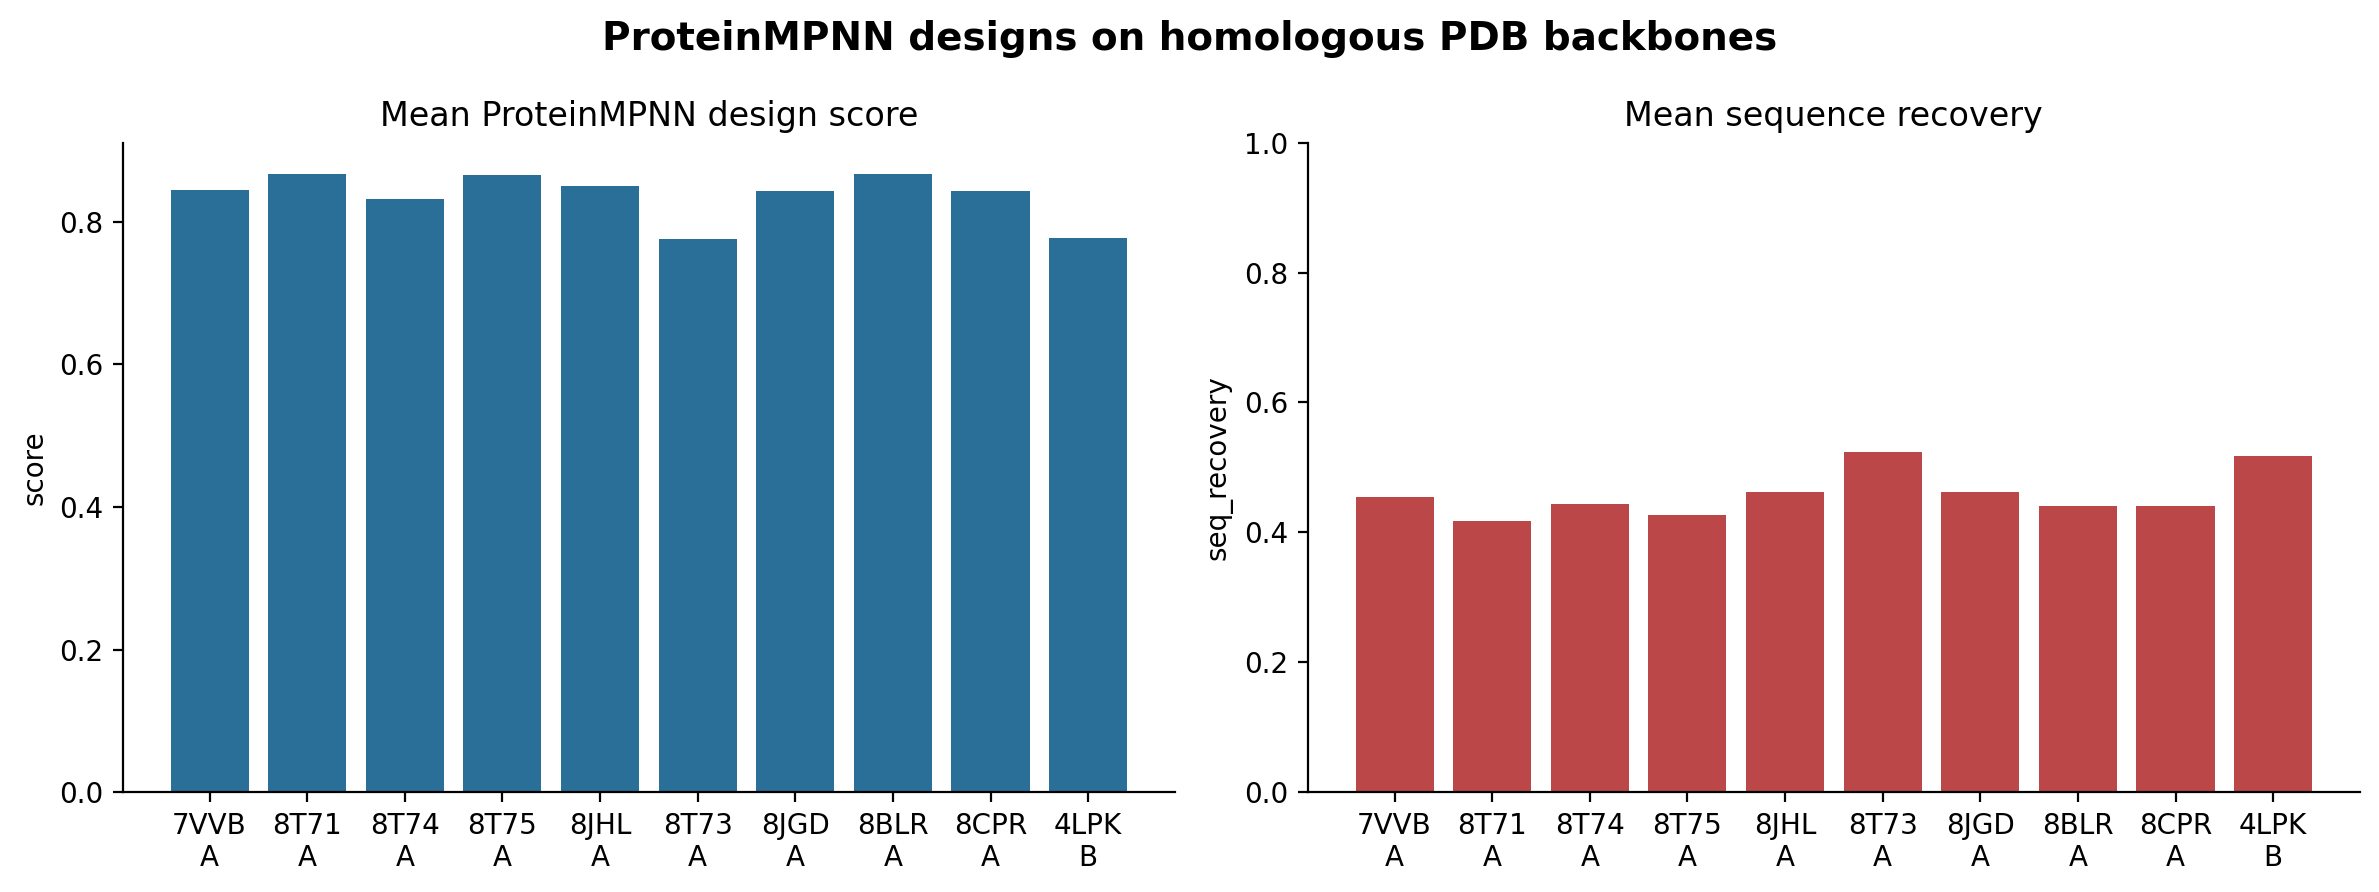

Saved figure: results/figures/sequenceTools_proteinmpnn_summary.png
Saved figure: results/figures/sequenceTools_proteinmpnn_summary.pdf


In [5]:
grouped = {}
for row in design_rows:
    grouped.setdefault(row['entry_id'], []).append(row)

entry_ids = list(grouped)
mean_scores = [sum(item['design_score'] for item in grouped[e] if item['design_score'] is not None) / len(grouped[e]) for e in entry_ids]
mean_recovery = [sum(item['seq_recovery'] for item in grouped[e] if item['seq_recovery'] is not None) / len(grouped[e]) for e in entry_ids]
labels = [f"{entry_id}\n{grouped[entry_id][0]['chain_id']}" for entry_id in entry_ids]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=200)
axes[0].bar(labels, mean_scores, color='#2a6f97')
axes[0].set_title('Mean ProteinMPNN design score')
axes[0].set_ylabel('score')
axes[0].tick_params(axis='x', rotation=0)

axes[1].bar(labels, mean_recovery, color='#bc4749')
axes[1].set_title('Mean sequence recovery')
axes[1].set_ylabel('seq_recovery')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)

fig.suptitle('ProteinMPNN designs on homologous PDB backbones', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(SUMMARY_PNG, dpi=300, bbox_inches='tight')
fig.savefig(SUMMARY_PDF, bbox_inches='tight')
plt.show()

print(f'Saved figure: {SUMMARY_PNG}')
print(f'Saved figure: {SUMMARY_PDF}')


## Interpretation

The generated sequences are **structure-conditioned designs**: they are not extracted from the PDB entries, but sampled by ProteinMPNN to be compatible with the backbone geometry of each homologous structure.

This makes the notebook useful for comparing how a family of homologous backbones constrains sequence design. The summary table and FASTA output can then be compared against native sequences, alignment-based similarities, or downstream analyses such as SSNs.
